In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
data_dir = '/Users/arpitkapoor/Library/CloudStorage/OneDrive-UNSW/Shared/Data/FEFLOW/simulation_files/'

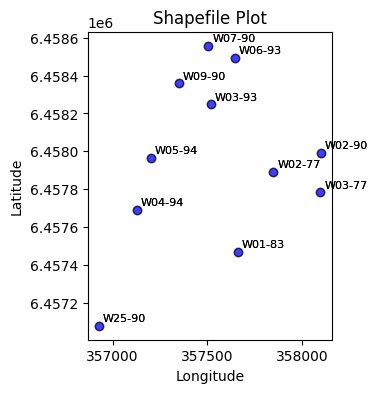

In [3]:
# Read shapefile
gdf = gpd.read_file(os.path.join(data_dir, 'observations_points.shp'))

# Plot with customization
fig, ax = plt.subplots(figsize=(6, 4))
gdf.plot(ax=ax, 
         color='blue', 
         edgecolor='black',
         alpha=0.5)
plt.title('Shapefile Plot')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Annotate each point using the 'LABEL' column (if present).
# Uses small offset and font size to avoid overlapping markers.

for idx, row in gdf.iterrows():
    # get point coordinates
    x, y = row.geometry.x, row.geometry.y
    label = row['LABEL']
    # annotate with a slight offset in points so marker remains visible
    ax.annotate(str(label), xy=(x, y), xytext=(3, 3), textcoords='offset points', fontsize=8)

In [4]:
# Time series data

In [5]:
pow_file = os.path.join(data_dir, 'observation_timesteps.pow')

# Read the .pow file
with open(pow_file, 'r') as file:
    lines = file.readlines()

variable_start = [lines.index(line) for line in lines if line.startswith('#')]
variable_end = variable_start[1:] + [len(lines)]

variable_start_end = list(zip(variable_start, variable_end))
variable_start_end

[(0, 2549),
 (2549, 24140),
 (24140, 36478),
 (36478, 36647),
 (36647, 36795),
 (36795, 36913),
 (36913, 37017),
 (37017, 37931),
 (37931, 37945),
 (37945, 39858),
 (39858, 41771),
 (41771, 43661),
 (43661, 44738)]

In [6]:
var_ts = {}

for var_start, var_end in variable_start_end:
    var_data = list(map(str.strip, lines[var_start+1: var_end]))
    var_name = var_data[0][1:].strip()
    var_metadata = var_data[1][1:].strip()

    if var_name.startswith('W'):
        print(f"Variable: {var_name}")
        print(f"Metadata: {var_metadata}")
        print(f"Line count: {len(var_data)-2} \n")

        var_data = var_data[2:-1]
        var_data = [ts for ts in var_data if not ts.startswith('END') and not ts.startswith('GAP')]

        var_data = np.array([list(map(float, line.split())) for line in var_data])

        var_ts[var_name] = pd.DataFrame(var_data[2:], columns=['Time', var_name]).set_index('Time')




Variable: W05-94HourlyHead
Metadata: [type=Constant;option=linear;timeunit=d;unitclass=CARDINAL;userunit=]
Line count: 21588 

Variable: W25_90HourlyHead
Metadata: [type=Constant;option=linear;timeunit=d;unitclass=CARDINAL;userunit=]
Line count: 12335 

Variable: W05-94HourlyHeadTidePeaks
Metadata: [type=Constant;option=linear;timeunit=d;unitclass=CARDINAL;userunit=]
Line count: 1887 

Variable: W25_90HourlyHeadTidePeaks
Metadata: [type=Constant;option=linear;timeunit=d;unitclass=CARDINAL;userunit=]
Line count: 1074 



In [7]:
var_names = list(var_ts.keys())
var_ts_df = pd.concat(list(var_ts.values()))
var_ts_df


,W05-94HourlyHead,W25_90HourlyHead,W05-94HourlyHeadTidePeaks,W25_90HourlyHeadTidePeaks
Time,,,,
0.666667,0.319425,NaN,NaN,NaN
0.708333,0.319325,NaN,NaN,NaN
0.750000,0.318625,NaN,NaN,NaN
0.791667,0.318525,NaN,NaN,NaN
0.833333,0.318025,NaN,NaN,NaN
...,...,...,...,...
897.416667,NaN,NaN,NaN,0.196533
898.083333,NaN,NaN,NaN,0.263586
898.458333,NaN,NaN,NaN,0.218750


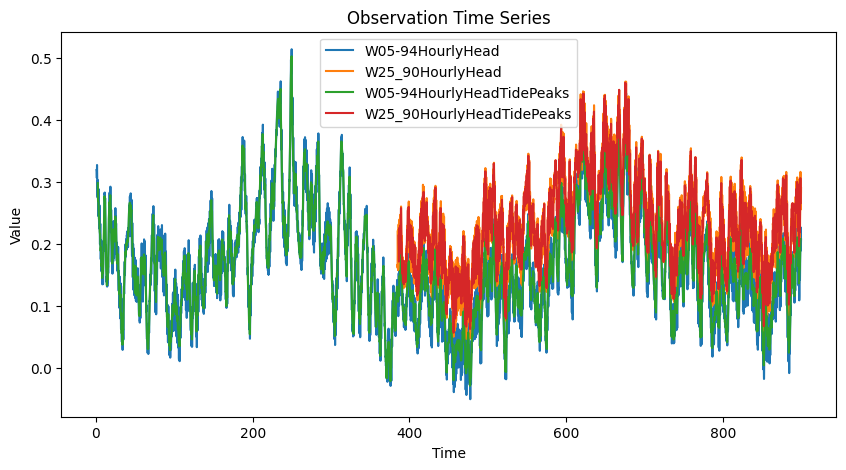

In [8]:
# plot time series for a variable

fig, ax = plt.subplots(figsize=(10, 5))

for var_name in var_names:
    ax.plot(var_ts[var_name].index, var_ts[var_name][var_name], label=var_name)

ax.set_title('Observation Time Series')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.legend()


array([ 3.57200998e+05,  6.45796500e+06, -2.00000000e+00])

In [23]:
obs_point_geometry = gdf.loc[gdf['LABEL'] == 'W05-94', ['X', 'Y', 'Z']].values[0]
ts = var_ts_df['W05-94HourlyHead']
obs_point_geometry

array([ 3.57200998e+05,  6.45796500e+06, -2.00000000e+00])